# 🏥 Evaluación Parcial — Minería de Datos
## Proceso KDD: Predicción de Enfermedades Cardíacas mediante Regresión Logística

---

| | |
|---|---|
| **Institución** | Centro Politécnico Superior Malvinas Argentinas |
| **Bloque** | Minería de Datos |
| **Tipo de evaluación** | Parcial Individual |
| **Duración** | 2 horas |
| **Condición** | Puede utilizarse material de consulta personal |

---

### 📝 Datos del estudiante

| Campo | Completar |
|-------|-----------|
| **Apellido y Nombre** | &nbsp; **Rodriguez Sade Ivan Emilio** |
| **DNI** | &nbsp; **29903256** |
| **Fecha de entrega** | &nbsp; **19/06/26** |

---

### 📋 Instrucciones generales

1. **Completá el código** en cada celda habilitada, reemplazando los comentarios `# TODO:` por el código correspondiente.
2. **Respondé las preguntas escritas** en las celdas de texto que aparecen debajo de cada consigna. Reemplazá el texto en *cursiva* por tu respuesta.
3. **Ejecutá todas las celdas en orden** antes de entregar. Un notebook con errores de ejecución no podrá ser evaluado.
4. **Entregá el archivo `.ipynb`** completo a través de la plataforma Moodle.

> ⚠️ **Advertencia:** El trabajo es individual. Se desestimará cualquier respuesta copiada de otro compañero o generada por Inteligencia Artificial, sin puntaje para el ítem involucrado.

---

### 🩺 Contexto del problema

El conjunto de datos a utilizar es el **Heart Disease Dataset** disponible en el repositorio oficial de la UCI:  
🔗 **https://archive.ics.uci.edu/dataset/45/heart+disease**

El dataset contiene información clínica de pacientes y el objetivo es predecir si un paciente presenta o no una **enfermedad cardíaca**.

**Variable objetivo (`target` / `num`):**
- `0` → El paciente **no presenta** enfermedad cardíaca
- `> 0` → El paciente **presenta** enfermedad cardíaca (puede binarizarse)

> 💡 **Tip:** Podés consumir el dataset de la forma que prefieras: descargarlo manualmente, usar la librería `ucimlrepo` (`pip install ucimlrepo`), o cualquier otro método válido.

---

### 📊 Distribución de puntaje

| Fase | Etapa KDD | Puntaje |
|------|-----------|:-------:|
| Fase 1 | Selección de Datos | 1 pto |
| Fase 2 | Preprocesamiento | 2.5 ptos |
| Fase 3 | Transformación | 2 ptos |
| Fase 4 | Modelado | 2 ptos |
| Fase 5 | Evaluación | 2.5 ptos |
| **Total** | | **10 ptos** |

> Nota mínima de aprobación: **6 / 10**


---
## ⚙️ Celda de configuración — No modificar

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS — No modificar esta celda
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## 📌 FASE 1 — Selección de Datos &nbsp;&nbsp; `[ 1 punto ]`

En el proceso **KDD**, la etapa de **Selección** consiste en identificar y cargar el subconjunto de datos relevante para el problema planteado.

En esta fase debés:
- Cargar el dataset desde la fuente oficial de la UCI
- Realizar una exploración inicial de su estructura
- Identificar las variables y la variable objetivo


In [2]:
# ============================================================
# TAREA 1.1 | Carga e inspección del dataset   [ 0.5 pto ]
# Fuente: https://archive.ics.uci.edu/dataset/45/heart+disease
# ============================================================

# Instalacion del paquete oficial de UCI
!pip install ucimlrepo -q

import pandas as pd
from ucimlrepo import fetch_ucirepo

# Cargo el dataset
heart_disease = fetch_ucirepo(id=45)

# Separo features (X) y target (y) y los unimos en un único DataFrame de trabajo
X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

# Muestro las primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [3]:
# Dimensiones del dataset (filas y columnas)
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 303
Columnas: 14


In [4]:
# Tipos de dato de cada columna
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


**✍️ Tarea 1.2 — Análisis de la etapa de Selección &nbsp; `[ 0.5 pto — Comprensión y Vocabulario ]`**

**1. ¿Qué representa cada instancia (fila) en este dataset?**

> Cada instancia o digamos fila, representa a un paciente que fue evaluado clínicamente por sospecha de enfermedad cardíaca en el Cleveland Clinic Foundation. Cada fila tiene un conjunto de mediciones clinicas y de diagnóstico (edad, presión arterial, colesterol, etc.) tomadas sobre ese paciente en particular, junto con el diagnóstico final respecto a la presencia de enfermedad coronaria.

**2. ¿Cuál es la variable objetivo? ¿Qué valores toma y qué significa cada uno en el contexto clínico?**

> La variable objetivo (target) es `num`, que indica el diagnóstico de enfermedad cardíaca del paciente. Toma valores enteros de 0 a 4: el valor 0 significa ausencia de enfermedad cardíaca, mientras que los valores 1, 2, 3 y 4 muestran presencia de enfermedad, con severidad creciente (numero mas grande, mayor grado de obstrucción o compromiso coronario detectado por angiografía).

**3. ¿Cuántas variables predictoras (features) tiene el dataset? Identificá al menos 3 y explicá brevemente qué información aporta cada una.**

> El dataset tiene 13 variables predictoras. Algunas de ellas son:
> - **age**: edad del paciente en años. Es de nivel relevante porque el riesgo cardiovascular aumenta con la edad.
> - **chol**: colesterol sérico en mg/dl. Niveles elevados de colesterol están asociados a mayor riesgo de enfermedad coronaria.
> - **thalach**: frecuencia cardíaca máxima alcanzada durante la prueba de esfuerzo. Una frecuencia máxima baja puede ser indicio de menor capacidad funcional del corazón.
> - **cp** (chest pain type): tipo de dolor de pecho informado por el paciente (angina típica, atípica, no anginoso o asintomático), es un indicador clínico clásico para sospechar enfermedad coronaria.

**4. ¿Por qué es relevante identificar el tipo de dato de cada variable antes de continuar con el proceso KDD?**

> Identificar si es, numérico, categórico u ordinal es fundamental porque determina qué tratamientos estadísticos y técnicas de preprocesamiento van a ser válidos para cada una. Por ejemplo, las variables numéricas continuas (como `chol` o `trestbps`) pueden normalizarse o estandarizarse, mientras que las categóricas (como `cp` o `thal`) requieren técnicas de codificación (One-Hot u Ordinal Encoding) antes de poder ser usadas en algoritmos de Machine Learning, que solo trabajan con valores numéricos.
Tambien, conocer el tipo de dato ayuda a detectar inconsistencias (por ejemplo, una variable categórica cargada como número) y a elegir correctamente los gráficos y métricas de análisis exploratorio (EDA) adecuados para cada tipo de variable.

---
## 📌 FASE 2 — Preprocesamiento &nbsp;&nbsp; `[ 2.5 puntos ]`

El **Preprocesamiento** evalúa y mejora la calidad del dataset. Comprende la detección de valores faltantes, el análisis estadístico, la distribución de clases y la identificación de valores atípicos.

En esta fase debés:
- Detectar y tratar valores nulos
- Analizar estadísticas descriptivas
- Explorar la distribución de la variable objetivo
- Visualizar la distribución de las variables numéricas para detectar outliers


In [5]:
# ============================================================
# TAREA 2.1 | Detección y tratamiento de valores nulos   [ 0.25 pto ]
# ============================================================

# Verifico la cantidad de valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de registros: {len(df)}")

Valores nulos por columna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Total de registros: 303


In [6]:
# Tratamiento de valores nulos
# Como son solo 6 registros sobre 303 (-2%) y están concentrados en 'ca' y 'thal',
# eliminamos esas filas en lugar de imputar, para no introducir valores artificiales
# en variables categóricas/ordinales de relevancia clínica.
df = df.dropna()

print(f"Filas luego de eliminar nulos: {df.shape[0]}")
print(f"\nValores nulos restantes:\n{df.isnull().sum().sum()}")

Filas luego de eliminar nulos: 297

Valores nulos restantes:
0


###**Justificacion:** Como son solo 6 registros sobre 303 (-2%) y están concentrados en 'ca' y 'thal', eliminamos esas filas en lugar de imputar, para no introducir valores artificiales en variables categóricas/ordinales de relevancia clínica.

In [7]:
# ============================================================
# TAREA 2.2 | Estadísticas descriptivas   [ 0.25 pto ]
# ============================================================

df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


/tmp/ipykernel_37254/3219246873.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df, palette='viridis')


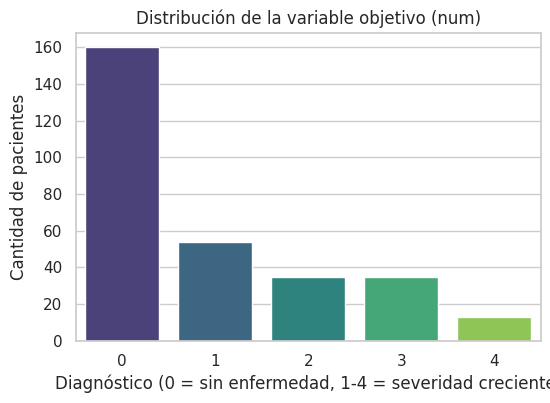

In [8]:
# ============================================================
# TAREA 2.3 | Distribución de la variable objetivo   [ 0.5 pto ]
# ============================================================

# Conteo de registros por clase
print(df['num'].value_counts().sort_index())

# Visualización con bar chart (Clase 4: ideal para comparar valores entre categorías)
plt.figure(figsize=(6, 4))
sns.countplot(x='num', data=df, palette='viridis')
plt.title('Distribución de la variable objetivo (num)')
plt.xlabel('Diagnóstico (0 = sin enfermedad, 1-4 = severidad creciente)')
plt.ylabel('Cantidad de pacientes')
plt.show()

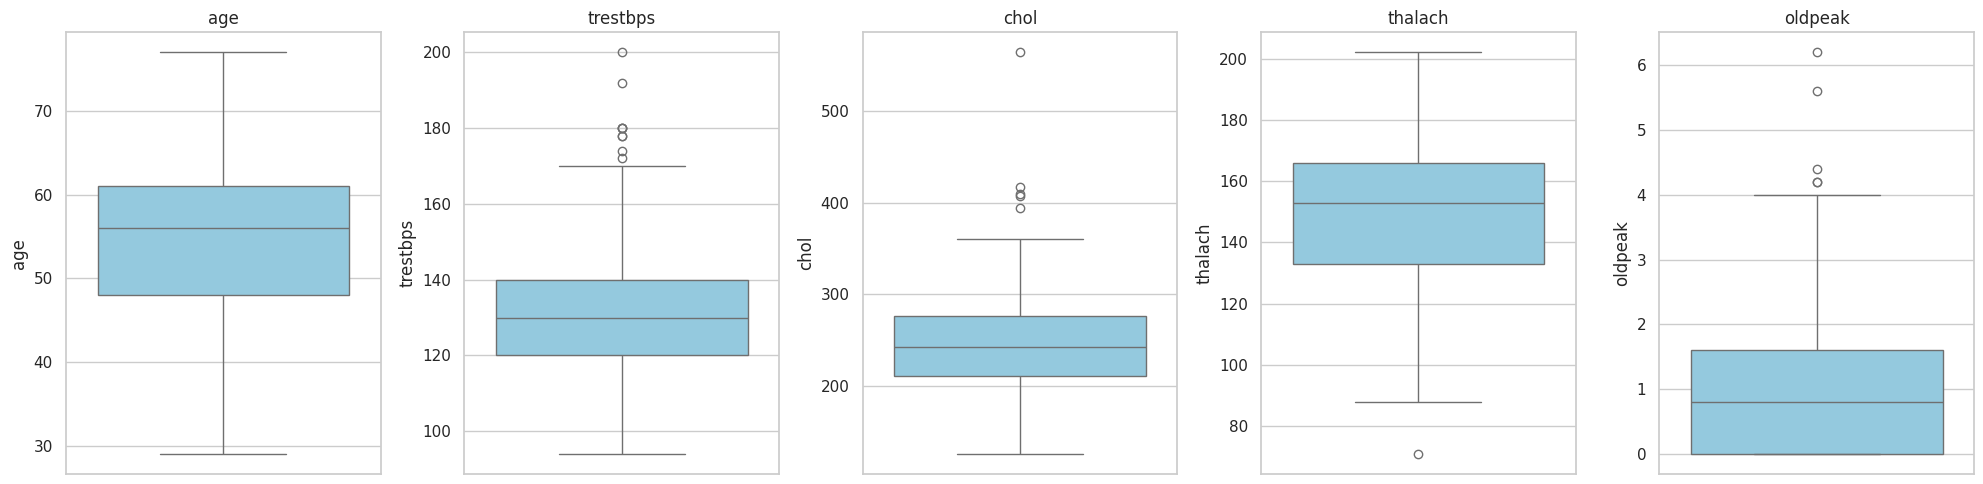

In [9]:
# ============================================================
# TAREA 2.4 | Detección de outliers — Boxplot   [ 0.5 pto ]
# ============================================================

# Variables numéricas continuas (excluyo las categóricas/binarias codificadas como números)
variables_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(variables_continuas), figsize=(20, 5))

for i, col in enumerate(variables_continuas):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

**Tarea 2.5 — Análisis del Preprocesamiento &nbsp; `[ 1 pto — Comprensión y Vocabulario ]`**

**1. ¿El dataset presentó valores nulos? ¿Qué estrategia de tratamiento aplicaste y por qué la considerás adecuada para este contexto?**

> Sí, el dataset presentó valores nulos: 4 registros con valor faltante en la variable `ca` (número de vasos principales coloreados por fluoroscopía) y 2 registros con valor faltante en `thal` (resultado de la prueba de talio), totalizando 6 filas afectadas sobre 303. Apliqué la estrategia de **eliminación de filas** (dropna), ya que la proporción de datos faltantes es muy baja (menos del 2% del total), por lo que el impacto en el tamaño de la muestra es mínimo y no se justifica el riesgo de sesgo que implicaría imputar valores en variables categóricas/ordinales de relevancia clínica como estas.

**2. Analizá el balance de clases: ¿el dataset está balanceado? ¿Qué consecuencias podría tener un desbalance significativo en el rendimiento de un clasificador?**

> El dataset **no está balanceado**: la clase 0 (ausencia de enfermedad) concentra la mayor cantidad de casos, mientras que las clases que indican presencia de enfermedad (1 a 4) están más repartidas y, en particular, las de mayor severidad (3 y 4) tienen muy pocos registros en comparación. Un desbalance significativo puede hacer que un clasificador aprenda a favorecer la clase mayoritaria, logrando una accuracy global alta de forma engañosa pero con bajo recall para las clases minoritarias. En este contexto clínico esto es especialmente grave, porque las clases minoritarias representan justamente los casos más severos, que son los más importantes de detectar correctamente.

**3. ¿Identificaste valores atípicos (outliers)? ¿En cuál/es variables? ¿Decidiste tratarlos o mantenerlos? Justificá tu decisión.**

> Sí, identifiqué outliers mediante boxplots en las variables continuas: 6 valores atípicos en "trestbps" (presión arterial en reposo), 4 en "chol" (colesterol), 1 en "thalach" (frecuencia cardíaca máxima) y 4 en "oldpeak" (depresión del segmento ST). Decidí **mantener** estos outliers en el dataset sin eliminarlos, ya que en un contexto clínico los valores extremos no necesariamente son errores de medición: pueden corresponder a pacientes con cuadros reales de hipertensión, colesterol muy elevado o fuerte respuesta isquémica al ejercicio, que son precisamente los casos de mayor interés diagnóstico. Eliminarlos arriesgaría a perder información relevante para distinguir pacientes con enfermedad más severa.

**4. ¿Qué patrones o características relevantes pudiste identificar en esta etapa que consideres importantes para el modelado?**

> Identifiqué que el dataset, luego de la limpieza, queda con 297 registros y combina variables numéricas continuas (age, trestbps, chol, thalach, oldpeak) con variables categóricas y ordinales codificadas numéricamente (sex, cp, fbs, restecg, exang, slope, ca, thal), por lo que será necesario aplicar una codificación adecuada antes del modelado. También noté el desbalance de clases en la variable objetivo y la presencia de outliers concentrados en "trestbps", "chol" y "oldpeak", dos aspectos que deberán tenerse en cuenta tanto en la elección del algoritmo de modelado como en la interpretación de las métricas de evaluación más adelante.

---
## 📌 FASE 3 — Transformación &nbsp;&nbsp; `[ 2 puntos ]`

La **Transformación** adapta los datos al formato y escala que el algoritmo requiere. Incluye la codificación de variables categóricas, la separación entre features y target, la división del dataset y el escalado de características.

En esta fase debés:
- Codificar las variables categóricas nominales
- Separar el dataset en variables predictoras (X) y variable objetivo (y)
- Dividir en conjuntos de entrenamiento y prueba
- Aplicar escalado de características con `StandardScaler`


In [10]:
# ============================================================
# TAREA 3.1 | Codificación de variables categóricas   [ 0.5 pto ]
# ============================================================

# Identificamos las variables categóricas nominales (sin orden lógico entre sus categorías).
# 'cp' (tipo de dolor de pecho) y 'restecg' (resultados electrocardiográficos) son nominales: sus
# valores numéricos son solo etiquetas de categorías distintas asique no representan una escala de magnitud.
# 'thal' también es nominal (normal / defecto fijo / defecto reversible).
# Nota importante: dejamos fuera las binarias (sex, fbs, exang) porque con 2 categorías el One-Hot
# no aporta información adicional respecto a dejarlas como están, y dejamos fuera 'slope'
# y 'ca' por tratarse de variables ordinales.

variables_categoricas_nominales = ['cp', 'restecg', 'thal']

print("Columnas ANTES del One-Hot Encoding:", df.shape[1])

# Aplicamos One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=variables_categoricas_nominales, drop_first=True)

print("Columnas DESPUÉS del One-Hot Encoding:", df_encoded.shape[1])
df_encoded.head()

Columnas ANTES del One-Hot Encoding: 14
Columnas DESPUÉS del One-Hot Encoding: 18


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,num,cp_2,cp_3,cp_4,restecg_1,restecg_2,thal_6.0,thal_7.0
0,63,1,145,233,1,150,0,2.3,3,0.0,0,False,False,False,False,True,True,False
1,67,1,160,286,0,108,1,1.5,2,3.0,2,False,False,True,False,True,False,False
2,67,1,120,229,0,129,1,2.6,2,2.0,1,False,False,True,False,True,False,True
3,37,1,130,250,0,187,0,3.5,3,0.0,0,False,True,False,False,False,False,False
4,41,0,130,204,0,172,0,1.4,1,0.0,0,True,False,False,False,True,False,False


In [11]:
# ============================================================
# TAREA 3.2 | Separación de features (X) y variable objetivo (y)   [ 0.25 pto ]
# ============================================================

#separo las variables predictoras X y la variable objetivo Y
X = df_encoded.drop(columns=['num'])
y = df_encoded['num']

# muestro las dimensiones de C/U
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (297, 17)
Dimensiones de y: (297,)


In [12]:
# ============================================================
# TAREA 3.3 | División en entrenamiento y prueba   [ 0.5 pto ]
# ============================================================

# Uso test_size=0.2 (80% train / 20% test): es un valor estándar que deja
# suficientes datos para entrenar (dataset moderado de ~297 registros) y a la vez
# un conjunto de prueba representativo. stratify=y preserva la proporción de cada
# clase en ambos conjuntos, lo cual es clave dado el desbalance detectado en la Fase 2.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# muestro cantidad de registros en cada conjunto
print(f"Registros en train: {X_train.shape[0]}")
print(f"Registros en test: {X_test.shape[0]}")

Registros en train: 237
Registros en test: 60


In [13]:
# ============================================================
# TAREA 3.4 | Escalado de características — StandardScaler   [ 0.75 pto ]
# ============================================================

scaler = StandardScaler()

# Ajusto (fit) SOLO con datos de entrenamiento y transformo ambos conjuntos,
# para evitar data leakage (que información del conjunto de test influya en el escalado)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificación: la media de cada columna en X_train_scaled debe ser ~0
print("Media de X_train_scaled (debería ser ≈ 0):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).mean().round(3))

Media de X_train_scaled (debería ser ≈ 0):
age         -0.0
sex         -0.0
trestbps     0.0
chol         0.0
fbs         -0.0
thalach      0.0
exang        0.0
oldpeak      0.0
slope       -0.0
ca          -0.0
cp_2        -0.0
cp_3         0.0
cp_4        -0.0
restecg_1    0.0
restecg_2   -0.0
thal_6.0     0.0
thal_7.0     0.0
dtype: float64


**✍️ Tarea 3.5 — Justificación de las decisiones de transformación &nbsp; `[ 0.5 pto — Comprensión y Vocabulario ]`**

**1. ¿Por qué es necesario aplicar escalado antes de entrenar un modelo de Regresión Logística? ¿Qué podría ocurrir si las variables tuviesen escalas muy diferentes?**

> La regresión logística estima sus coeficientes optimizando una función de costo mediante métodos basados en gradiente, y es sensible a la escala de las variables predictoras. Si las variables tuviesen escalas muy diferentes (por ejemplo, "chol" con valores de cientos y "oldpeak" con valores entre 0 y 6), las variables de mayor magnitud dominarían el cálculo de la función de costo y el proceso de optimización, haciendo que el algoritmo les asigne más peso no porque sean más relevantes para predecir la enfermedad, sino simplemente por su escala numérica. Esto puede hacer que la convergencia del modelo sea más lenta o inestable, y que los coeficientes resultantes no reflejen correctamente la verdadera importancia de cada variable.

**2. ¿Por qué el `StandardScaler` debe ajustarse exclusivamente con los datos de entrenamiento? ¿Qué problema introduce hacerlo sobre todo el dataset?**

> El "StandardScaler" calcula la media y el desvío estándar de cada variable para luego transformarla. Si se ajusta (fit) sobre todo el dataset, incluyendo el conjunto de test, esas estadísticas estarían "contaminadas" con información del conjunto de prueba, lo cual constituye un caso de **data leakage** (fuga de datos): el modelo terminaría entrenándose de forma indirecta con información que en un escenario real no debería conocer en el momento de entrenar. Esto genera una evaluación del modelo demasiado optimista, ya que el desempeño medido en test no reflejaría fielmente cómo se comportaría el modelo ante datos verdaderamente nuevos. Por eso el ajuste se hace solo con "X_train", y luego ese mismo escalador (ya ajustado) se usa únicamente para transformar tanto "X_train" como "X_test".

**3. ¿Qué proporción elegiste para `test_size`? ¿Cuál es la función del parámetro `stratify` en la división?**

> Elegí "test_size=0.2", es decir, un 80% de los datos para entrenamiento y un 20% para prueba. Es una proporción estándar que permite contar con suficientes datos para que el modelo aprenda patrones robustos, dado que el dataset es de tamaño moderado (297 registros), y a la vez deja un conjunto de test representativo para evaluar el desempeño. El parámetro "stratify=y" asegura que la proporción de cada clase de la variable objetivo se mantenga igual tanto en el conjunto de entrenamiento como en el de prueba. Esto es especialmente importante en este dataset porque, como se identificó en la Fase 2, las clases están desbalanceadas: sin estratificar, una división aleatoria simple podría dejar muy pocos (o ningún) registro de las clases minoritarias (3 y 4) en el conjunto de test, dificultando una evaluación confiable del modelo para esos casos.

---
## 📌 FASE 4 — Modelado (Minería de Datos) &nbsp;&nbsp; `[ 2 puntos ]`

La **Minería de Datos** es el núcleo del proceso KDD. En esta etapa se aplica el algoritmo de aprendizaje automático elegido para descubrir patrones en los datos.

El algoritmo a implementar es la **Regresión Logística**, un clasificador supervisado que estima la probabilidad de que una instancia pertenezca a una clase.

> **Parámetros clave de `LogisticRegression`:**
> - `C`: inverso de la fuerza de regularización (valores altos = menos regularización)
> - `solver`: algoritmo de optimización (`'lbfgs'`, `'liblinear'`, `'saga'`)
> - `max_iter`: número máximo de iteraciones hasta convergencia
> - `random_state`: semilla para resultados reproducibles


In [15]:
# ============================================================
# TAREA 4.1 | Instanciación y entrenamiento del modelo   [ 1 pto ]
# ============================================================

# Instancio LogisticRegression con los siguientes parámetros:
# - C=1.0: valor por defecto, regularización moderada.
#   Es un buen punto de partida razonable sin evidencia previa de sobreajuste/subajuste.
# - solver='lbfgs': es el solver por defecto de scikit-learn, soporta problemas
#   multiclase de forma nativa (softmax) y funciona bien en datasets de tamaño
#   pequeño/moderado como este.
# - max_iter=1000: aumento el valor por defecto (100) para asegurar la convergencia
#   del algoritmo de optimización, dado que el dataset tiene varias variables dummy
#   generadas por el One-Hot Encoding.
# - random_state=42: garantiza reproducibilidad de los resultados.

modelo_lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento ESCALADOS
modelo_lr.fit(X_train_scaled, y_train)

# Mostramos los parámetros configurados del modelo
print("Parámetros del modelo entrenado:")
print(modelo_lr.get_params())

Parámetros del modelo entrenado:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


**✍️ Tarea 4.2 — Justificación de parámetros del modelo &nbsp; `[ 1 pto — Comprensión y Vocabulario ]`**

**1. ¿Qué valor de `C` elegiste? ¿Qué controla este parámetro? ¿Qué ocurre cuando `C` es muy pequeño? ¿Y cuando es muy grande?**

> Elegí "C=1.0", el valor por defecto de scikit-learn. Este parámetro controla la **fuerza de la regularización**, es decir, cuánto se penaliza la complejidad del modelo (la magnitud de sus coeficientes) durante el entrenamiento. Es el inverso de la fuerza de regularización: a menor valor de "C", mayor regularización aplicada. Cuando "C" es muy pequeño, la regularización es muy fuerte y el modelo tiende a simplificarse demasiado, "achicando" los coeficientes hacia cero; esto puede provocar **subajuste (underfitting)**, ya que el modelo pierde capacidad de capturar relaciones reales entre las variables y la clase. Cuando "C" es muy grande, la regularización es casi nula y el modelo puede ajustar los coeficientes libremente para minimizar el error en el conjunto de entrenamiento, lo que aumenta el riesgo de **sobreajuste (overfitting)**, perdiendo capacidad de generalización ante datos nuevos. Usé el valor por defecto como punto de partida razonable, ya que no había evidencia previa de que el modelo necesitara una regularización más agresiva o más laxa.

**2. ¿Qué `solver` seleccionaste y por qué es apropiado para este problema?**

> Seleccioné el solver "lbfgs", que es el utilizado por defecto en scikit-learn. Es apropiado para este problema porque maneja de forma nativa la clasificación **multiclase** (nuestra variable objetivo "num" tiene 5 clases, de 0 a 4) mediante un esquema de optimización tipo softmax, sin necesidad de configuraciones adicionales. Además, es un solver eficiente y recomendado para datasets de tamaño pequeño a mediano, como el de este trabajo (297 registros), y soporta regularización L2, que es la que se aplica por defecto junto con el parámetro "C".

**3. ¿Qué representa el parámetro `max_iter`? ¿Qué indicaría un error de convergencia al entrenar el modelo?**

> El parámetro "max_iter" representa el número máximo de iteraciones que el algoritmo de optimización (en este caso, "lbfgs") puede realizar para intentar encontrar los coeficientes que minimizan la función de costo del modelo. Configuré "max_iter=1000", por encima del valor por defecto (100), para darle más margen al algoritmo. Un **error de convergencia** (warning de tipo "ConvergenceWarning") indicaría que el algoritmo alcanzó el número máximo de iteraciones sin haber encontrado un mínimo estable de la función de costo, es decir, que el proceso de optimización no terminó de converger. Esto puede deberse a que las variables no están en una escala adecuada (de ahí la importancia del escalado previo con "StandardScaler") o a que se necesitan más iteraciones para que el algoritmo termine de ajustar los coeficientes correctamente.

---

#**PASO PREVIO AL PUNTO 5, PORQUE ME OLVIDE DE BINARIZAR**

In [16]:
# ============================================================
# NOTA METODOLÓGICA -Binarización de la variable objetivo
# ============================================================
# La variable 'num' original tiene 5 clases (0 = sin enfermedad, 1-4 = severidad
# creciente). Entonces convierto el problema a clasificación BINARIA:
# 0 = ausencia de enfermedad, 1 = presencia de enfermedad (agrupando las clases 1-4).
# Esto permite aplicar las métricas clásicas de clasificación binaria (matriz de
# confusión 2x2, Curva ROC y AUC).

y_train_bin = (y_train > 0).astype(int)
y_test_bin = (y_test > 0).astype(int)

print("Distribución de clases en y_train_bin:")
print(y_train_bin.value_counts())
print("\nDistribución de clases en y_test_bin:")
print(y_test_bin.value_counts())

# Re-entreno el modelo de Regresión Logística con el target binario
modelo_lr = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train_bin)

Distribución de clases en y_train_bin:
num
0    128
1    109
Name: count, dtype: int64

Distribución de clases en y_test_bin:
num
0    32
1    28
Name: count, dtype: int64


LogisticRegression(max_iter=1000, random_state=42)

---
## 📌 FASE 5 — Evaluación &nbsp;&nbsp; `[ 2.5 puntos ]`

La **Evaluación** determina si los patrones descubiertos por el modelo son útiles y confiables. Se utilizan múltiples métricas dado que ninguna es suficiente por sí sola.

| Métrica | Descripción |
|---------|-------------|
| **Accuracy** | Proporción de predicciones correctas sobre el total |
| **Precision** | De los casos predichos como positivos, ¿cuántos lo son realmente? |
| **Recall (Sensibilidad)** | De todos los casos positivos reales, ¿cuántos detectó el modelo? |
| **F1-Score** | Media armónica entre Precision y Recall |
| **AUC-ROC** | Capacidad del modelo de distinguir entre clases en todos los umbrales |


In [17]:
# ============================================================
# TAREA 5.1 | Predicciones sobre el conjunto de prueba   [ 0.25 pto ]
# ============================================================

# Predicciones de clase (0 o 1)
y_pred = modelo_lr.predict(X_test_scaled)

# Probabilidades de predicción (necesarias para la Curva ROC)
# tomamos la columna 1: probabilidad de pertenecer a la clase positiva (enfermedad)
y_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print("Primeras 10 predicciones:", y_pred[:10])
print("Primeras 10 probabilidades:", y_proba[:10].round(3))

Primeras 10 predicciones: [0 0 0 0 0 0 0 0 1 0]
Primeras 10 probabilidades: [0.008 0.006 0.046 0.061 0.046 0.203 0.232 0.044 0.937 0.287]


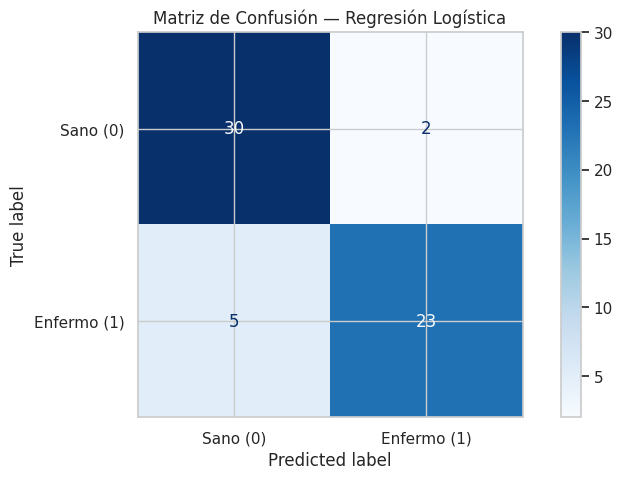

Verdaderos Negativos (TN): 30
Falsos Positivos (FP): 2
Falsos Negativos (FN): 5
Verdaderos Positivos (TP): 23


In [18]:
# ============================================================
# TAREA 5.2 | Matriz de Confusión   [ 0.5 pto ]
# ============================================================

cm = confusion_matrix(y_test_bin, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Enfermo (1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión — Regresión Logística')
plt.show()

# Valores por separado
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

In [19]:
# ============================================================
# TAREA 5.3 | Reporte de clasificación   [ 0.5 pto ]
# ============================================================

print("Reporte de clasificación:\n")
print(classification_report(y_test_bin, y_pred, target_names=['Sano (0)', 'Enfermo (1)']))

accuracy = accuracy_score(y_test_bin, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Reporte de clasificación:

              precision    recall  f1-score   support

    Sano (0)       0.86      0.94      0.90        32
 Enfermo (1)       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60

Accuracy: 0.8833


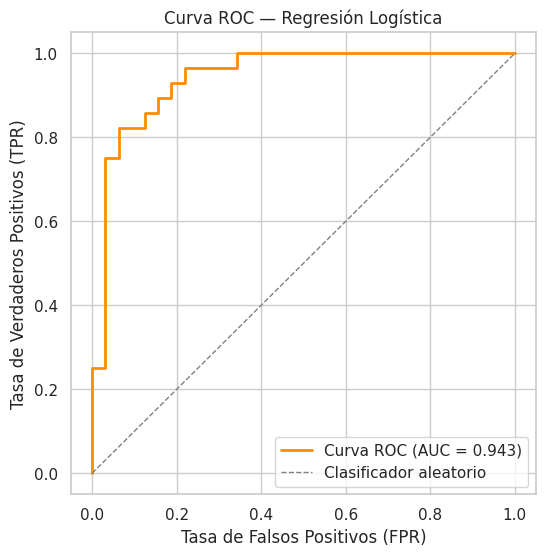

AUC Score: 0.9431


In [20]:
# ============================================================
# TAREA 5.4 | Curva ROC y AUC Score   [ 0.75 pto ]
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
auc_score = roc_auc_score(y_test_bin, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Regresión Logística')
plt.legend(loc='lower right')
plt.show()

print(f"AUC Score: {auc_score:.4f}")

**✍️ Tarea 5.5 — Interpretación de resultados en contexto clínico &nbsp; `[ 1.5 ptos — Comprensión y Vocabulario ]`**

**1. Completá la siguiente tabla con los valores obtenidos en la Matriz de Confusión y describí qué representa cada caso en el contexto clínico:**

| | Predicho: Sin enfermedad | Predicho: Con enfermedad |
|---|---|---|
| **Real: Sin enfermedad** | Verdadero Negativo (TN) = 30 | Falso Positivo (FP) = 2 |
| **Real: Con enfermedad** | Falso Negativo (FN) = 5 | Verdadero Positivo (TP) = 23 |

> En contexto clínico, cada celda representa lo siguiente:
> - **TN (30):** pacientes sanos que el modelo correctamente identificó como sin enfermedad. No reciben estudios ni tratamientos innecesarios.
> - **FP (2):** pacientes sanos que el modelo clasificó incorrectamente como enfermos. Esto generaría estudios adicionales o preocupación innecesaria, pero no pone en riesgo directo la salud del paciente.
> - **FN (5):** pacientes que efectivamente tienen la enfermedad pero el modelo los clasificó como sanos. Es el error más peligroso, ya que estos pacientes no recibirían el seguimiento o tratamiento que necesitan, al creer (erróneamente) que están sanos.
> - **TP (23):** pacientes enfermos que el modelo identificó correctamente, permitiendo iniciar el seguimiento o tratamiento adecuado a tiempo.

**2. ¿Cuál error es más grave desde la perspectiva médica: un Falso Negativo o un Falso Positivo? ¿Por qué?**

> El **Falso Negativo es el error más grave** en este contexto clínico. Un Falso Positivo implica someter a un paciente sano a estudios adicionales innecesarios, lo cual genera un costo y una molestia, pero no pone en riesgo su salud. En cambio, un Falso Negativo significa decirle a un paciente que está sano cuando en realidad tiene una enfermedad cardíaca, lo que puede retrasar el diagnóstico y el tratamiento, con consecuencias potencialmente graves o irreversibles para su salud (incluyendo el riesgo de un evento cardíaco no prevenido). En diagnóstico médico, generalmente se prioriza minimizar los Falsos Negativos, incluso a costa de aumentar algo los Falsos Positivos.

**3. ¿Qué métrica debería priorizarse para evaluar este modelo: Precision o Recall? ¿Los valores obtenidos son satisfactorios? Justificá con los números.**

> Debería priorizarse el **Recall** (sensibilidad) de la clase "Enfermo", ya que mide la capacidad del modelo de detectar correctamente a los pacientes que realmente tienen la enfermedad, minimizando los Falsos Negativos (el error más grave, según el punto anterior). En este modelo, el Recall para la clase "Enfermo (1)" fue de **0.82**, lo que significa que el modelo detectó correctamente al 82% de los pacientes enfermos, mientras que el 18% restante (5 de 28 pacientes enfermos) no fueron detectados (Falsos Negativos). Si bien la Precision para esa misma clase fue alta (0.92), en un contexto clínico el valor de Recall de 0.82 indica que **el modelo es bueno pero perfectible**: aún deja sin detectar a una proporción no despreciable de pacientes enfermos, por lo que no debería usarse como única herramienta de diagnóstico sin supervisión médica adicional.

**4. ¿Qué información adicional aporta la Curva ROC respecto al Accuracy? Interpretá el valor de AUC obtenido.**

> El Accuracy es un único número calculado con un umbral de decisión fijo (0.5 por defecto), y puede ser engañoso en datasets con cierto desbalance de clases. La Curva ROC, en cambio, muestra el comportamiento del modelo (relación entre Tasa de Verdaderos Positivos y Tasa de Falsos Positivos) **a lo largo de todos los umbrales de decisión posibles**, permitiendo evaluar la capacidad del modelo para separar las clases independientemente del punto de corte elegido. El AUC (Area Under the Curve) resume esa curva en un solo valor: en este caso, **AUC = 0.9431**, lo cual indica una **muy buena capacidad de discriminación** del modelo entre pacientes sanos y enfermos (un valor de 0.5 equivaldría a un clasificador aleatorio, y 1.0 a un clasificador perfecto). Este resultado sugiere que, más allá del umbral de 0.5 usado para las métricas anteriores, el modelo ordena correctamente a la gran mayoría de los pacientes según su probabilidad real de enfermedad, y que ajustar el umbral de decisión podría mejorar el Recall sin perder demasiada Precision.

**5. ¿Considerás que este modelo sería adecuado para asistir a profesionales de la salud en la detección de enfermedades cardíacas? ¿Qué limitaciones identificás?**

> El modelo muestra un desempeño sólido (Accuracy = 0.88, AUC = 0.94) y podría ser una **herramienta de apoyo (no de reemplazo)** para profesionales de la salud, por ejemplo como sistema de alerta temprana o de priorización de pacientes para estudios más exhaustivos. Sin embargo, identifico varias limitaciones importantes:
> - El **Recall de 0.82** implica que aproximadamente 1 de cada 5 pacientes enfermos no sería detectado por el modelo, algo inaceptable como única fuente de diagnóstico en medicina.
> - El conjunto de test es **pequeño** (60 pacientes), por lo que las métricas obtenidas tienen cierta variabilidad y deberían confirmarse con más datos o validación cruzada.
> - El dataset proviene de una única institución (Cleveland Clinic), por lo que el modelo podría no generalizar bien a poblaciones con características demográficas o clínicas distintas.
> - Se simplificó el problema original (5 niveles de severidad) a una clasificación binaria, perdiendo información sobre el grado de severidad de la enfermedad, que también es clínicamente relevante.
>
> Por estas razones, el modelo es prometedor como apoyo a la decisión clínica, pero siempre debería usarse en conjunto con la evaluación de un profesional médico y no de forma autónoma.

---

---

# 📊 Rúbrica de Evaluación

> **Para uso exclusivo del docente — El estudiante no debe completar esta sección**

---

## Criterio 1 — Aplicación de Herramientas y Software `[ 30% = 3 puntos ]`

| Fase | Ítem evaluado | Ptje. máx. | Ptje. obtenido | Observaciones |
|------|---------------|:----------:|:--------------:|---------------|
| Fase 1 | Carga del dataset, uso de `.head()`, `.shape`, `.info()` / `.dtypes` | 0.5 | | |
| Fase 2 | Uso de `.isnull()`, `.describe()`, `value_counts()`, gráfico de barras y boxplots | 1.0 | | |
| Fase 3 | Aplicación de encoding, `train_test_split`, `StandardScaler` (fit/transform separados) | 1.0 | | |
| Fase 4 | Instanciación de `LogisticRegression` con parámetros explícitos y `.fit()` | 0.5 | | |
| Fase 5 | `predict`, `predict_proba`, `ConfusionMatrixDisplay`, `classification_report`, `roc_curve` | 1.0 | | |
| | **SUBTOTAL** | **4.0 → 3.0** | | *Ponderado al 30%* |

---

## Criterio 2 — Comprensión del Proceso y Análisis de Resultados `[ 40% = 4 puntos ]`

| Fase | Ítem evaluado | Ptje. máx. | Ptje. obtenido | Observaciones |
|------|---------------|:----------:|:--------------:|---------------|
| Fase 1 | Identifica correctamente instancias, features y variable objetivo | 0.5 | | |
| Fase 2 | Analiza balance de clases, outliers y patrones con criterio fundado | 1.0 | | |
| Fase 3 | Justifica escalado, data leakage y uso de `stratify` | 0.5 | | |
| Fase 4 | Comprende y fundamenta la elección de `C`, `solver` y `max_iter` | 1.0 | | |
| Fase 5 | Interpreta FP/FN en contexto clínico; argumenta métrica prioritaria; analiza AUC | 1.0 | | |
| | **SUBTOTAL** | **4.0** | | |

---

## Criterio 3 — Organización, Documentación y Vocabulario `[ 30% = 3 puntos ]`

| Aspecto | Excelente | Bueno | Regular | Insuficiente | Ptje. |
|---------|:---------:|:-----:|:-------:|:------------:|:-----:|
| **Vocabulario técnico** (KDD, instancia, feature, target, outlier, data leakage, regularización, etc.) | 1.0 | 0.75 | 0.5 | 0 | |
| **Calidad de respuestas escritas** (profundidad, coherencia, argumentación) | 1.0 | 0.75 | 0.5 | 0 | |
| **Organización del notebook** (celdas ejecutadas, sin errores, entrega completa) | 1.0 | 0.75 | 0.5 | 0 | |
| | | | | **SUBTOTAL** | **/3.0** |

---

## 🏆 Síntesis Final

| Criterio | Peso | Puntaje obtenido |
|----------|:----:|:----------------:|
| Aplicación de Herramientas y Software | 30% | &nbsp;&nbsp; / 3.0 |
| Comprensión del Proceso y Análisis | 40% | &nbsp;&nbsp; / 4.0 |
| Organización, Documentación y Vocabulario | 30% | &nbsp;&nbsp; / 3.0 |
| **TOTAL** | **100%** | **/ 10.0** |

---

**Nota Final:** _________ / 10 &nbsp;&nbsp;&nbsp; | &nbsp;&nbsp;&nbsp; **Condición:** ☐ Aprobado (≥ 6) &nbsp;&nbsp; ☐ Desaprobado (< 6)

**Docente evaluador/a:** ___________________________________ &nbsp;&nbsp; **Fecha:** ___________

**Observaciones:**

> &nbsp;
